# Data Visualization & Exploratory Data Analysis (EDA)

**Author:** Yi Wang, An Nisa Astuti

## Purpose
This notebook contains **in-progress exploratory** EDA and visualization code for our project.  

## Data Inputs (pre-cleaned)
This notebook **does not re-scrape or re-pull APIs**. It reads the outputs produced by our data pipelines:

1. **311 metrics (computed from raw 311 requests):** `data/311_metrics.csv`  

2. **ACS SES (Census API, aggregated to Chicago community areas):** `data/acs_community_area_ses_2020_2024.csv`  

### Exploratory plots (in-progress)
Examples of plots generated in this notebook:
- 311 request volume over time (by year)
- 311 responsiveness trend (e.g., volume-weighted median time-to-close by year)
- Distribution of responsiveness metrics (e.g., histogram of `median_ttc_hours`)
- ACS SES distributions (e.g., poverty rate, SNAP, rent burden, etc.)
- correlation heatmap for ACS SES features

In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [23]:
acs = pd.read_csv("data/acs_community_area_ses_2020_2024.csv")
m311 = pd.read_csv("data/311_metrics.csv")

# Coerce numeric columns in 311_metrics (important)
m311_num = [
    "community_area","year","ward",
    "n_requests","n_closed","share_closed",
    "median_ttc_hours","p75_ttc_hours",
    "n_open","share_open",
    "pct_closed_24h","pct_closed_72h","pct_closed_7d","pct_closed_30d"
]
for c in m311_num:
    if c in m311.columns:
        m311[c] = pd.to_numeric(m311[c], errors="coerce")

print("ACS:", acs.shape)
print("311_metrics:", m311.shape)

display(acs.head(3))
display(m311.head(3))


ACS: (77, 19)
311_metrics: (1394, 19)


,community_area,community_name,total_population,poverty_rate,median_household_income_weighted,unemployment_rate,pct_less_than_hs,pct_bachelor_plus,snap_rate,public_assist_rate,rent_burden_30p_rate,rent_burden_50p_rate,crowding_rate,pct_renter,vacancy_rate,no_vehicle_rate,pct_white_non_hispanic,pct_black_non_hispanic,pct_hispanic
0,1,ROGERS PARK,49628,0.1840,64218.0,0.0743,0.1219,0.5176,0.1627,0.0446,0.4925,0.2351,0.0516,0.7133,0.0908,0.3604,0.4194,0.2312,0.2416
1,2,WEST RIDGE,78373,0.1929,71554.0,0.0733,0.1279,0.4388,0.2072,0.0353,0.5336,0.2907,0.0843,0.4938,0.0769,0.1499,0.3937,0.1171,0.2058
2,3,UPTOWN,56344,0.1845,74039.0,0.0470,0.0727,0.6087,0.1464,0.0350,0.4687,0.2188,0.0237,0.7072,0.0912,0.4285,0.5197,0.1901,0.1415


,community_area,year,ward,n_requests,n_closed,share_closed,n_open,share_open,median_ttc_hours,p75_ttc_hours,mean_ttc_hours,median_age_open_hours,p75_age_open_hours,pct_closed_24h,pct_closed_72h,pct_closed_7d,pct_closed_30d,small_n_requests,small_n_closed
0,1,2021,40.0,489,487,0.9959,2,0.0041,65.8528,403.3588,987.2005,40425.7935,41301.9181,0.3436,0.5215,0.6442,0.8303,False,False
1,1,2021,49.0,8226,8117,0.9867,109,0.0133,62.9389,485.9081,1065.8087,38986.7958,41413.5375,0.3820,0.5179,0.6071,0.7755,False,False
2,1,2021,50.0,24,24,1.0000,0,0.0000,0.8431,45.3127,1196.4521,NaN,NaN,0.7083,0.7917,0.8333,0.8333,True,True


In [24]:
# Keys check
print("ACS community_area unique:", acs["community_area"].nunique())
print("311_metrics community_area unique:", m311["community_area"].nunique())
print("311_metrics years:", sorted(m311["year"].dropna().unique()))

# Missingness tables
display(acs.isna().mean().sort_values(ascending=False).head(12).to_frame("missing_rate"))
display(m311.isna().mean().sort_values(ascending=False).head(12).to_frame("missing_rate"))

# Descriptive stats
acs_vars = [
    "poverty_rate","unemployment_rate","pct_less_than_hs","pct_bachelor_plus",
    "snap_rate","public_assist_rate",
    "rent_burden_30p_rate","rent_burden_50p_rate",
    "crowding_rate","pct_renter","vacancy_rate","no_vehicle_rate",
    "median_household_income_weighted"
]
acs_vars = [c for c in acs_vars if c in acs.columns]
display(acs[acs_vars].describe())

m311_vars = [
    "n_requests","share_closed","median_ttc_hours","p75_ttc_hours",
    "share_open","pct_closed_7d","pct_closed_30d"
]
m311_vars = [c for c in m311_vars if c in m311.columns]
display(m311[m311_vars].describe())


ACS community_area unique: 77
311_metrics community_area unique: 77
311_metrics years: [np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025)]


,missing_rate
community_area,0.0
rent_burden_30p_rate,0.0
pct_black_non_hispanic,0.0
pct_white_non_hispanic,0.0
no_vehicle_rate,0.0
vacancy_rate,0.0
pct_renter,0.0
crowding_rate,0.0
rent_burden_50p_rate,0.0
public_assist_rate,0.0


,missing_rate
median_age_open_hours,0.157819
p75_age_open_hours,0.157819
ward,0.021521
p75_ttc_hours,0.001435
median_ttc_hours,0.001435
mean_ttc_hours,0.001435
small_n_requests,0.000000
pct_closed_30d,0.000000
pct_closed_7d,0.000000
pct_closed_72h,0.000000


,poverty_rate,unemployment_rate,pct_less_than_hs,pct_bachelor_plus,snap_rate,public_assist_rate,rent_burden_30p_rate,rent_burden_50p_rate,crowding_rate,pct_renter,vacancy_rate,no_vehicle_rate,median_household_income_weighted
count,77.000000,77.000000,77.000000,77.000000,77.000000,77.000000,77.000000,77.000000,77.000000,77.000000,77.000000,77.000000,77.000000
mean,0.191400,0.102517,0.139129,0.368122,0.238439,0.042470,0.517256,0.282138,0.036055,0.503303,0.095212,0.235890,74168.129870
std,0.114004,0.058306,0.087375,0.221210,0.155652,0.021029,0.100366,0.095692,0.025066,0.188827,0.052731,0.127274,31011.934738
min,0.048300,0.031600,0.017700,0.046300,0.025400,0.007700,0.305200,0.099300,0.000000,0.116500,0.025800,0.033400,16990.000000
25%,0.103800,0.054400,0.071100,0.187000,0.114600,0.027200,0.445500,0.205200,0.017600,0.356300,0.060100,0.119100,52172.000000
50%,0.173500,0.082200,0.127900,0.297500,0.202800,0.038800,0.516200,0.274100,0.030100,0.516000,0.081100,0.222400,69083.000000
75%,0.255500,0.152100,0.183900,0.475200,0.349200,0.052800,0.597100,0.356400,0.050400,0.637700,0.125000,0.336800,91672.000000
max,0.619800,0.302400,0.353600,0.868300,0.682600,0.115600,0.708500,0.462500,0.103800,0.895600,0.252000,0.542000,158658.000000


,n_requests,share_closed,median_ttc_hours,p75_ttc_hours,share_open,pct_closed_7d,pct_closed_30d
count,1394.000000,1394.000000,1392.000000,1392.000000,1394.000000,1394.000000,1394.000000
mean,6354.802726,0.961780,609.927978,1180.188042,0.038220,0.598545,0.770183
std,43177.395000,0.083252,3232.761614,4020.406388,0.083252,0.172437,0.170467
min,1.000000,0.000000,0.000000,0.000300,0.000000,0.000000,0.000000
25%,319.250000,0.959050,37.597625,227.524700,0.006625,0.537000,0.743000
50%,1855.000000,0.982750,70.020800,405.603200,0.017250,0.603450,0.802250
75%,4535.500000,0.993375,118.527125,650.219200,0.040950,0.686175,0.846500
max,667862.000000,1.000000,32986.461100,37847.419700,1.000000,1.000000,1.000000


### 311 Visualization

#### Request by Year (2021-2025)

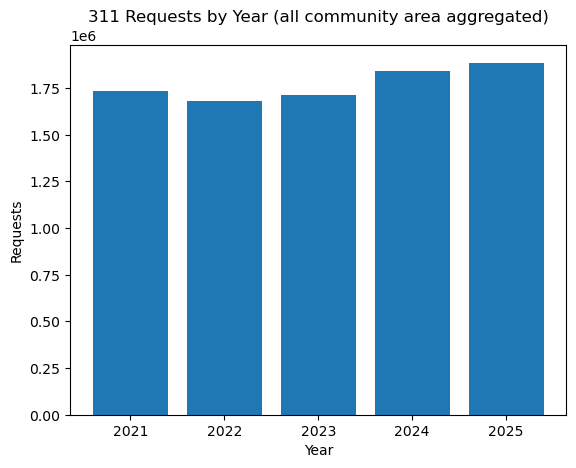

,year,n_requests
0,2021,1732797
1,2022,1683682
2,2023,1714519
3,2024,1841089
4,2025,1886508


In [25]:
vol_year = m311.groupby("year", as_index=False)["n_requests"].sum()

plt.figure()
plt.bar(vol_year["year"].astype(int).astype(str), vol_year["n_requests"])
plt.title("311 Requests by Year (all community area aggregated)")
plt.xlabel("Year")
plt.ylabel("Requests")
plt.show()

display(vol_year)

#### Volume-weighted median time-to-close by year

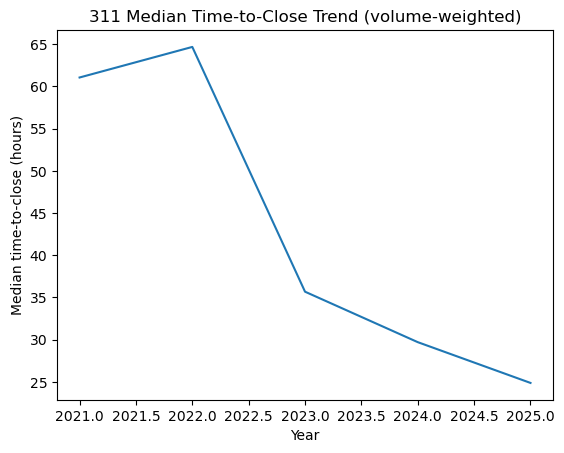

,year,n_requests,median_ttc_wavg,p75_ttc_wavg
0,2021,1732796.0,61.053602,360.557842
1,2022,1683682.0,64.675592,340.802164
2,2023,1714519.0,35.681071,192.343743
3,2024,1841089.0,29.704553,143.138050
4,2025,1886507.0,24.875474,140.551675


In [26]:
yearly = (
    m311.dropna(subset=["year","n_requests","median_ttc_hours"])
        .groupby("year", as_index=False)
        .apply(lambda g: pd.Series({
            "n_requests": g["n_requests"].sum(),
            "median_ttc_wavg": np.average(g["median_ttc_hours"], weights=g["n_requests"]),
            "p75_ttc_wavg": np.average(g["p75_ttc_hours"], weights=g["n_requests"]) if g["p75_ttc_hours"].notna().any() else np.nan
        }))
)

plt.figure()
plt.plot(yearly["year"], yearly["median_ttc_wavg"])
plt.title("311 Median Time-to-Close Trend (volume-weighted)")
plt.xlabel("Year")
plt.ylabel("Median time-to-close (hours)")
plt.show()

display(yearly)

#### Distribution of Median Time-to-Close

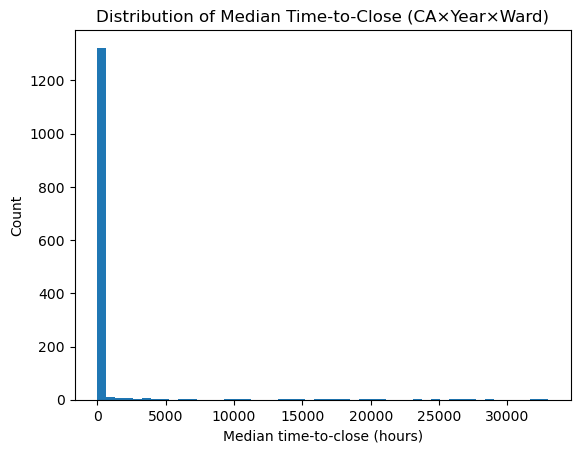

In [27]:
plt.figure()
m311["median_ttc_hours"].dropna().plot(kind="hist", bins=50)
plt.title("Distribution of Median Time-to-Close (CA×Year×Ward)")
plt.xlabel("Median time-to-close (hours)")
plt.ylabel("Count")
plt.show()

### ACS Data Visualization

#### 

In [28]:
acs.columns

Index(['community_area', 'community_name', 'total_population', 'poverty_rate',
       'median_household_income_weighted', 'unemployment_rate',
       'pct_less_than_hs', 'pct_bachelor_plus', 'snap_rate',
       'public_assist_rate', 'rent_burden_30p_rate', 'rent_burden_50p_rate',
       'crowding_rate', 'pct_renter', 'vacancy_rate', 'no_vehicle_rate',
       'pct_white_non_hispanic', 'pct_black_non_hispanic', 'pct_hispanic'],
      dtype='str')

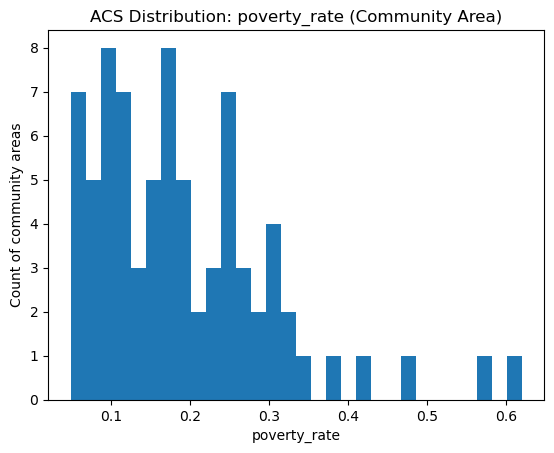

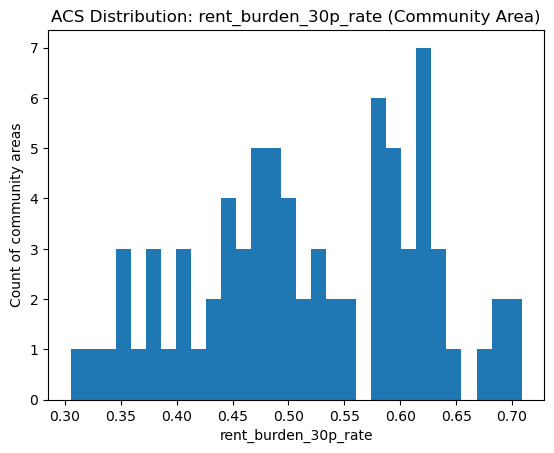

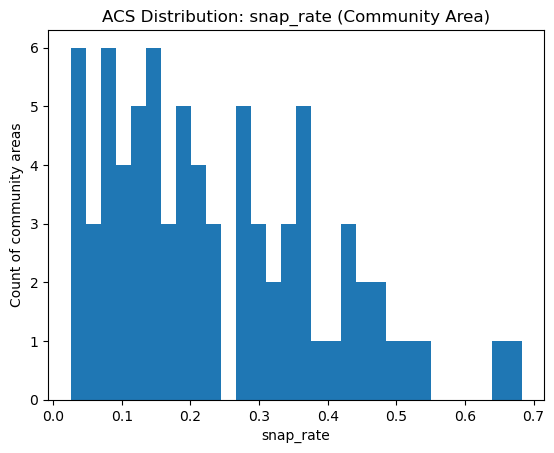

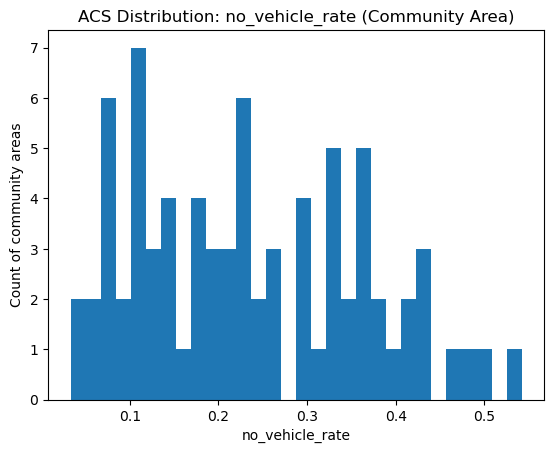

In [29]:
plot_vars = [c for c in ["poverty_rate","rent_burden_30p_rate","snap_rate","no_vehicle_rate"] if c in acs.columns]

for v in plot_vars:
    plt.figure()
    acs[v].dropna().plot(kind="hist", bins=30)
    plt.title(f"ACS Distribution: {v} (Community Area)")
    plt.xlabel(v)
    plt.ylabel("Count of community areas")
    plt.show()

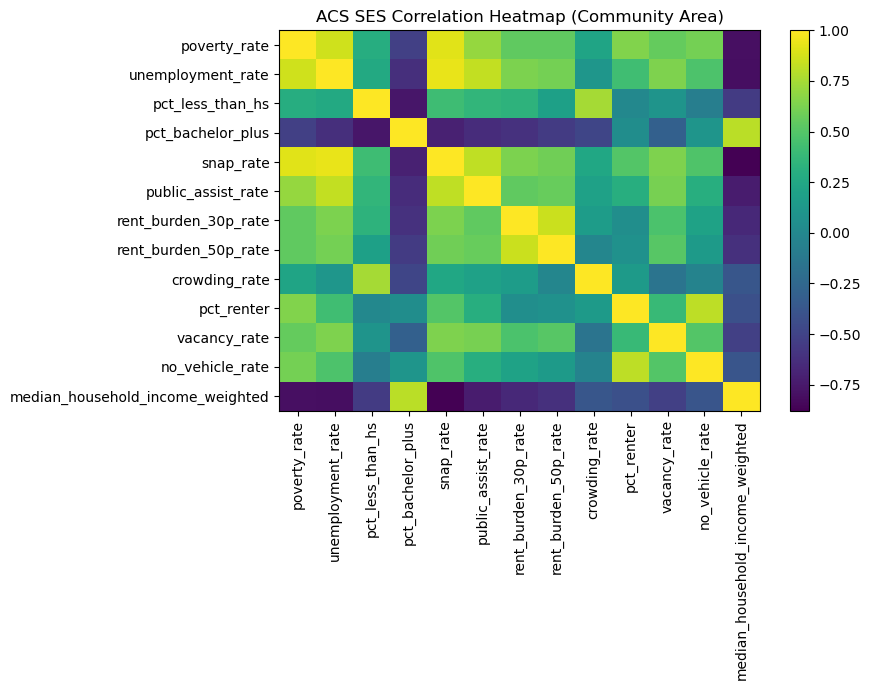

In [ ]:
corr_vars = [c for c in acs_vars if c in acs.columns]
corr = acs[corr_vars].corr(numeric_only=True)

plt.figure(figsize=(9, 7))
plt.imshow(corr, aspect="auto")
plt.xticks(range(len(corr_vars)), corr_vars, rotation=90)
plt.yticks(range(len(corr_vars)), corr_vars)
plt.title("ACS SES Correlation Heatmap (Community Area)")
plt.colorbar()
plt.tight_layout()a
plt.show()

### 